In [9]:
import os
print(os.listdir(images_dir)[:5])

['matplot', 'statista']


In [4]:
import os
statista_path = os.path.join(images_dir, 'statista')

if os.path.exists(statista_path):
    print("Files in Statista folder:", os.listdir(statista_path)[:5])
else:
    print("Could not find 'statista' folder. Check your path again.")

Files in Statista folder: ['0.png', '1.png', '10.png', '100.png', '1000.png']


Loading text files...
Successfully loaded 5703 records.

--- EXAMPLE #0 ---


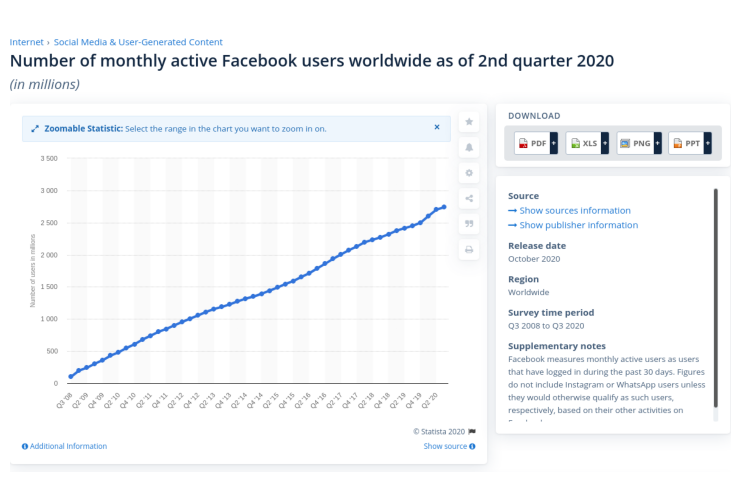

Image Source: D:\Projects\Spectra\Chart2TextImages-main\images\statista\0.png

Title:
Global spending on motorsports sponsorships 2011 to 2017

Summary:
This statistic shows the worldwide templateYLabel[0] for templateTitle[2] sponsorship from templateXValue[min] to templateXValue[max] . In the templateXLabel[0] templateXValue[4] , the templateTitleSubject[0] templateTitle[2] sponsorship templateYLabel[0] amounted to templateYValue[4] templateScale templateYLabel[2] templateYLabel[3] .

Data Table:


,Year,Spending in billion U.S. dollars
0,2017,5.75
1,2016,5.58
2,2015,5.43
3,2014,5.26
4,2013,5.12
5,2012,4.97
6,2011,4.83


In [8]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

dataset_path = r'D:\Projects\Spectra\Chart2Text-master\data\train'
images_dir = r'D:\Projects\Spectra\Chart2TextImages-main\images'

data_file = os.path.join(dataset_path, 'trainData.txt')
summary_file = os.path.join(dataset_path, 'trainSummary.txt')
title_file = os.path.join(dataset_path, 'trainTitle.txt')

print("Loading text files...")
with open(data_file, 'r', encoding='utf-8') as f:
    data_lines = [line.strip() for line in f.readlines()]

with open(summary_file, 'r', encoding='utf-8') as f:
    summary_lines = [line.strip() for line in f.readlines()]

with open(title_file, 'r', encoding='utf-8') as f:
    title_lines = [line.strip() for line in f.readlines()]

print(f"Successfully loaded {len(data_lines)} records.")


def find_image_path(idx):
    """
    Searches for the image in 'statista' and 'matplot' subfolders.
    Returns the full path if found, or None.
    """
    img_name = f"{idx}.png" 

    path_statista = os.path.join(images_dir, 'statista', img_name)
    if os.path.exists(path_statista):
        return path_statista

    path_matplot = os.path.join(images_dir, 'matplot', img_name)
    if os.path.exists(path_matplot):
        return path_matplot
        
    return None

def parse_chart_data(raw_string):
    """
    Parses the raw pipe-separated string into a clean list of dictionaries.
    Example Input: "Year|2017|x|... Spending|5.75|y|..."
    """
    tokens = raw_string.split()
    parsed_data = []
    current_row = {}
    
    for token in tokens:
        parts = token.split('|')
        if len(parts) >= 2:

            key = parts[0].replace('_', ' ')
            value = parts[1]
            current_row[key] = value

            if 'y' in parts:
                parsed_data.append(current_row)
                current_row = {}
                
    return parsed_data

def show_example(idx):
    """
    Displays the image, title, summary, and a clean data table for a given index.
    """
    print(f"\n--- EXAMPLE #{idx} ---")
    
    img_path = find_image_path(idx)
    if img_path:
        img = mpimg.imread(img_path)
        plt.figure(figsize=(10, 6)) 
        plt.imshow(img)
        plt.axis('off') 
        plt.show()
        print(f"Image Source: {img_path}")
    else:
        print(f"❌ ERROR: Could not find image {idx}.png in statista or matplot folders.")

    print(f"\nTitle:\n{title_lines[idx]}")
    print(f"\nSummary:\n{summary_lines[idx]}")

    print("\nData Table:")
    raw_data = data_lines[idx]
    cleaned_data = parse_chart_data(raw_data)
    
    if cleaned_data:
        df = pd.DataFrame(cleaned_data)
        display(df)
    else:
        print("No parsable data found.")
        
show_example(0)